In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
rikinzala_speech_emotion_recognition_model_cnn_lstm_part_1_path = kagglehub.notebook_output_download('rikinzala/speech-emotion-recognition-model-cnn-lstm-part-1')

print('Data source import complete.')


Data source import complete.


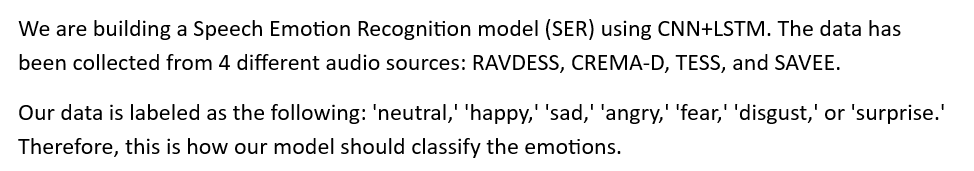

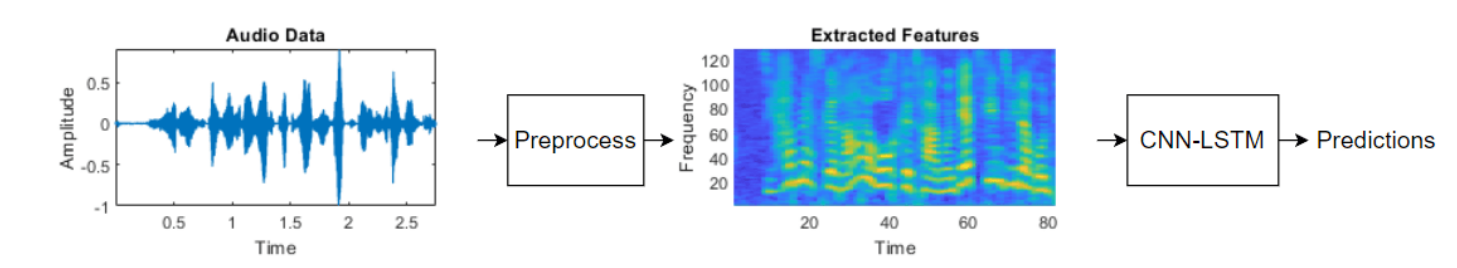

The example above trains a 2-D CNN-LSTM network to recognize the emotion 

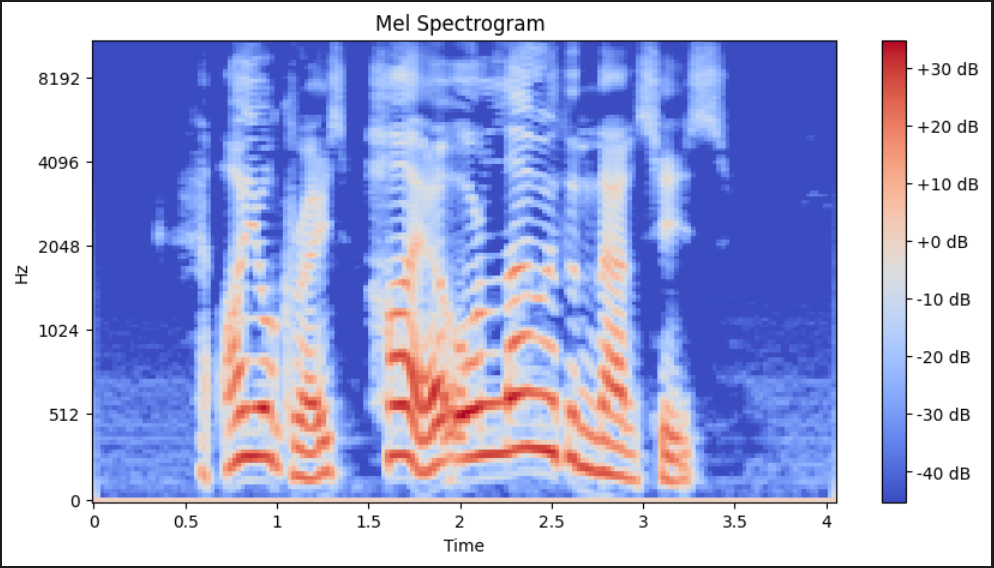

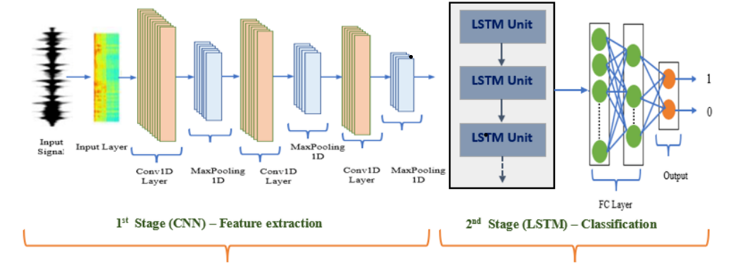

https://www.kaggle.com/code/rikinzala/speech-emotion-recognition-model-cnn-lstm-part-1 -> the notebook where we got our data for our model 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim #this is for the optimizer
#to not get warnings when building the nn
import warnings
warnings.filterwarnings('ignore')
from torch.utils.data import Dataset, random_split, DataLoader, Subset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
emotions_df = pd.read_csv('/kaggle/input/rikinzala/speech-emotion-recognition-model-cnn-lstm-part-1/emotion.csv')
emotions_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotions
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,-1.517691,-1.716481,-1.599312,-1.234615,-0.693200,-0.038981,0.675205,1.405603,2.112302,surprise
1,0.249512,0.371094,0.494629,0.487305,0.450195,0.416992,0.373047,0.337402,0.333496,0.333008,...,1.221636,1.231226,4.829375,-2.660280,-2.523232,0.690448,-3.171180,-4.200538,0.267294,surprise
2,0.304199,0.427246,0.540039,0.471191,0.387207,0.333008,0.282227,0.259277,0.258789,0.252930,...,0.518293,0.838663,1.308726,1.855110,2.405185,2.896439,3.283485,3.541677,3.667470,surprise
3,0.257324,0.390625,0.510254,0.520020,0.499512,0.505859,0.493652,0.469238,0.480957,0.458496,...,-2.230192,0.787118,-3.272193,-2.678341,-4.033977,0.941363,3.609636,5.748407,5.765827,surprise
4,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,2.586420,2.746858,2.223281,0.986924,-0.730691,-2.530884,-4.002835,-4.849377,-4.929749,neutral


In [6]:
emotions_df.isna().sum().sum() #to see how many null values are there

28245624

In [7]:
#here where we need to seperate the data points (X) from the labels (Y or "actual results")
X=emotions_df.iloc[:,:-1]
x=X.values
labels=labels=emotions_df['Emotions']
print(labels.head())
labels=labels.values

0    surprise
1    surprise
2    surprise
3    surprise
4     neutral
Name: Emotions, dtype: object


In [8]:
emotions_df.shape

(48648, 2377)

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
#fit only the training data in standard scalar and OneHotEncoder and just transform the testing no prevent data leakage on our training data
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test= train_test_split(x, labels, test_size=0.2, random_state=42)

x_train=np.nan_to_num(x_train, nan=0.0)
x_test=np.nan_to_num(x_test, nan=0.0) #one way to deal with nan data in time series is to change nan=0
#(other ways can depend on the context on the sequence, all in all ,never drop the nan data)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

ohe=OneHotEncoder()
y_train=ohe.fit_transform(y_train.reshape(-1, 1))
y_test=ohe.transform(y_test.reshape(-1, 1))

In [10]:
num_classes=7 #this should be 7 cause we will be classifying 7 different emotions
input_length=2376 #from our emotions_df.head() code we can see we have col 0-2375 numeric columns, those are our input_length
#batch_size=64 #the usual starting point in training a model but we will cross validate the batch anyways

In [ ]:
# in pytorch documentation it says:
# "A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. " and we have a custom dataset that isnt part of the dataset pytorch library
# "The __init__ function is run once when instantiating the Dataset object.
# The __len__ function returns the number of samples in our dataset.
# The __getitem__ function loads and returns a sample from the dataset at the given index idx. Based on the index, it identifies the image’s location on disk,
#converts that to a tensor using read_image, retrieves the corresponding label from the csv data in self.img_labels, calls the transform functions on them (if applicable),
#and returns the tensor image and corresponding label in a tuple." in our case the label will correspond with the feature
# the documentation site: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [12]:
#we must change our data to tensors in order for them to be passed in the model
#my 1d cnn expects input as (batch size, number of channels, input length)
#now we will have one channel so number of channels=1

# Define dataset_prep as a class that inherits from torch.utils.data.Dataset
class dataset_prep(Dataset):
    # The __init__ function is run once when instantiating the Dataset object.
    def __init__(self, features, labels):
        # Convert features and labels to tensors
        # Ensure labels are long for CrossEntropyLoss
        self.features = torch.tensor(features, dtype=torch.float32)
        # If labels are one-hot encoded, we need to get the class index
        # Assuming labels are one-hot encoded after preprocessing
        if labels.ndim > 1 and labels.shape[1] > 1:
             # Convert one-hot encoding back to class indices
             self.labels = torch.argmax(torch.tensor(labels.toarray(), dtype=torch.long), dim=1)
        else:
            # If labels are already class indices, convert directly
            self.labels = torch.tensor(labels, dtype=torch.long)


    # The __len__ function returns the number of samples in our dataset.
    def __len__(self):
        return len(self.labels)

    # The __getitem__ function loads and returns a sample from the dataset at the given index idx.
    def __getitem__(self, idx): # Add 'idx' as an argument as required by PyTorch
        x = self.features[idx].unsqueeze(0)
        y = self.labels[idx]
        return x, y

        #self.features[idx] has shape (2376,)
        #unsqueeze(0) changes it to (1, 2376) meaning 1 channel
        #then,our batch will be shaped like: (batch_size, 1, 2376), which is what conv1d expects.

# in pytorch documentation it says:
# "A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. " and we have a custom dataset that isnt part of the dataset pytorch library
# "The __init__ function is run once when instantiating the Dataset object.
# The __len__ function returns the number of samples in our dataset.
# The __getitem__ function loads and returns a sample from the dataset at the given index idx. Based on the index, it identifies the image’s location on disk,
#converts that to a tensor using read_image, retrieves the corresponding label from the csv data in self.img_labels, calls the transform functions on them (if applicable),
#and returns the tensor image and corresponding label in a tuple." in our case the label will correspond with the feature
# the documentation site: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

train_dataset=dataset_prep(x_train,y_train)
test_dataset=dataset_prep(x_test,y_test)

#as for dataloaders (also found in documentation)
#While training a model, we typically want to pass samples in “minibatches”,
#reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval.

In [13]:
train_dataset=dataset_prep(x_train,y_train)
test_dataset=dataset_prep(x_test,y_test)

In [ ]:
#as for dataloaders (also found in documentation)
#While training a model, we typically want to pass samples in “minibatches”,
#reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval.

In [15]:
from sklearn.model_selection import KFold

#in the following function we will be training. But the evaluation is only to save the best model weight and not to actually evaluate the model
#also we will add an early stopping "patience", this means if the model is converging after a
#certin amount of epochs it will stop training
def train_model(model,train_loader,val_loader,epochs=50,patience=10):
    optimizer=optim.Adam(model.parameters(),lr=0.001)
    criterion=nn.CrossEntropyLoss() #softmax is done here for the classification part
#and thats why u cant see softmax in the model

    #in order to keep track of our model at its best state we will do the following:
    best_val_loss=float('inf')
    patience_counter=0
    best_state=None

    for epoch in range(num_epochs):
        #the training part
        model.train()
        for inputs,labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device) #will speed up the process as this will send our data to kaggle gpus
            optimiser.zero_grad()
            outputs=model(inputs)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()

        #now the validation part
        model.eval()
        val_los=0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs=model(inputs)
                loss=criterion(outputs,labels)
                val_loss+=loss.item()

        #here we are just looking fo the best val loss (the min amount of less)
        #afterwards we will save the model when the val loss is at its lowest
        val_loss/=len(val_loader)
        if val_loss<best_val_loss:
            best_val_loss=val_loss
            best_state=model.state_dict()#saving the model state or model weights when finding a new min val loss
            patience_counter=0 #means the model hasnt convereged yet and we cant stop the epochs now cause we can still find better
        else:
            patience_counter+=1
        if patience_counter>= patience:
            break

    model.load_state_dict(best_state) #we have loaded the model


#in this function we will actually evaluate the model and know its accuarcy score
def evaluate_model(model, data_loader):
    model.eval()
    correct_pred=0
    total=0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs=model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total+=labels.size(0)
            correct_pred+=(predicted==labels).sum().item()
    return correct_pred/total

In [16]:
# This is a k-cross validation technique with kernel_size as an additional parameter
from itertools import product

params = {
    "dropout": [0.2],
    "batch_size": [32],
    "epochs": [15],
    "kernel_size": [(9,7,5), (7,5,3)]  # Different kernel sizes for the 3 conv layers
}

params_combined = list(product(*params.values()))

best_acc = 0  # best accuracy score
best_params = None  # best parameters
best_model = None  # best weights

# Convert data to tensor
x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.argmax(torch.tensor(y_train.toarray(), dtype=torch.long), dim=1) if hasattr(y_train, 'toarray') else torch.tensor(y_train, dtype=torch.long)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN1D_LSTM(nn.Module):
    # Add kernel_sizes as an argument with a default value
    def __init__ (self, input_length=2376, num_classes=12, dropout_rate=0.25, kernel_sizes=(9, 7, 5)):
        super(CNN1D_LSTM,self).__init__()

        # Use the provided kernel_sizes
        self.conv1 = nn.Conv1d(1, 32, kernel_size=kernel_sizes[0], stride=1)
        self.maxpool1 = nn.MaxPool1d(3, stride=2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=kernel_sizes[1], stride=1)
        self.bn1 = nn.BatchNorm1d(64) #to normalize the values in a batch
        self.maxpool2 = nn.MaxPool1d(3, stride=2)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=kernel_sizes[2], stride=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.maxpool3 = nn.MaxPool1d(3, stride=2)

        self.drop = nn.Dropout(dropout_rate)

        # this will help us to estimate output length after 3 MaxPool1d layers with stride=2 and kernel=3
        # we have created a dummy input that will be dynamically passed in the model
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, input_length)
            # Ensure the dummy input calculation matches the forward pass logic
            x = F.elu(self.conv1(dummy_input))
            x = self.maxpool1(x)
            x = F.elu(self.conv2(x))
            x = self.bn1(x)
            x = self.maxpool2(x)
            x = F.elu(self.conv3(x))
            x = self.bn2(x)
            x = self.maxpool3(x)

            self.seq_len = x.shape[2]

        self.lstm = nn.LSTM(input_size=128, hidden_size=32, batch_first=True, bidirectional=False) 
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * self.seq_len, num_classes)# u flatten the output and give it to a linear layer to predict emotion classes


    def forward(self,x): #this the base of our model, it tells u how we want to pass our data through every layer 
        x = F.elu(self.conv1(x)) #elu can be better than Relu in some audio tasks
        x = self.maxpool1(x)
        x = F.elu(self.conv2(x))
        x = self.bn1(x)
        x = self.maxpool2(x)
        x = F.elu(self.conv3(x))
        x = self.bn2(x)
        x = self.maxpool3(x)
        x = self.drop(x)
        x = x.permute(0, 2, 1) #this is for preparing the data for lstm input-> (batchsize, sequence length, features)
        x, _ = self.lstm(x)
        x = self.flatten(x)
        x = self.fc(x) #classification layer with num_classes output
        return x

In [19]:
import os
from datetime import datetime

# Create a directory to save models if it doesn't exist
os.makedirs('saved_models', exist_ok=True)


In [20]:
# This is a k-cross validation technique with kernel_size as an additional parameter
for dropout, batch_size, epochs, kernel_sizes in params_combined:
    print(f"\nEvaluating: dropout={dropout}, batch_size={batch_size}, epochs={epochs}, kernel_sizes={kernel_sizes}")

    # Create a subdirectory for this parameter combination
    param_str = f"dropout{dropout}_batch{batch_size}_epochs{epochs}_kernels{'-'.join(map(str, kernel_sizes))}"
    os.makedirs(f'saved_models/{param_str}', exist_ok=True)

    val_scores = []
    kfolds = KFold(n_splits=3, shuffle=True, random_state=42)

    # Convert train and test data to tensors BEFORE KFold
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    if hasattr(y_train, 'toarray'): # If y_train is a sparse matrix from OneHotEncoder
        y_train_tensor = torch.argmax(torch.tensor(y_train.toarray(), dtype=torch.long), dim=1)
    else: # If y_train is already class indices
        y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    # KFold splits the indices of the training dataset only
    for fold, (train_fold_idx, val_fold_idx) in enumerate(kfolds.split(x_train_tensor)):
        print(f"\nFold {fold + 1}/3")
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Create datasets
        train_dataset = torch.utils.data.TensorDataset(x_train_tensor[train_fold_idx].unsqueeze(1), y_train_tensor[train_fold_idx])
        val_dataset = torch.utils.data.TensorDataset(x_train_tensor[val_fold_idx].unsqueeze(1), y_train_tensor[val_fold_idx])

        # Create dataloaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        # Initialize model with current kernel sizes
        model = CNN1D_LSTM(
            input_length=x_train_tensor.shape[1],
            num_classes=len(ohe.categories_[0]),
            dropout_rate=dropout,
            kernel_sizes=kernel_sizes
        )
        model = model.to(device)

        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        best_val_loss = float('inf')
        patience = 10
        patience_counter = 0
        current_fold_best_state = None
        fold_loss_history = []

        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            # Save model checkpoint every epoch
            epoch_save_path = f'saved_models/{param_str}/fold{fold+1}_epoch{epoch+1}_{timestamp}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': train_loss/len(train_loader),
            }, epoch_save_path)

            # Validation
            model.eval()
            val_loss = 0
            correct = 0
            total = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()

                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            val_loss /= len(val_loader)
            val_acc = correct / total
            fold_loss_history.append(val_loss)

            # Early stopping and save best model for this fold
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                current_fold_best_state = model.state_dict()
                # Save the best model for this fold
                fold_best_save_path = f'saved_models/{param_str}/fold{fold+1}_best_{timestamp}.pth'
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': current_fold_best_state,
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': best_val_loss,
                    'val_acc': val_acc,
                }, fold_best_save_path)
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

        # Save loss history for this fold
        with open(f'saved_models/{param_str}/fold{fold+1}_loss_history_{timestamp}.txt', 'w') as f:
            f.write('\n'.join(map(str, fold_loss_history)))

        # Load best model state for the current fold
        if current_fold_best_state:
            model.load_state_dict(current_fold_best_state)

        # Final evaluation on validation set for the current fold
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        val_scores.append(val_acc)
        print(f"Fold {fold + 1} Validation Accuracy: {val_acc:.4f}")

    # Calculate mean validation accuracy across folds for this parameter combination
    mean_val_acc = np.mean(val_scores)
    print(f"\nMean Validation Accuracy: {mean_val_acc:.4f} for params: dropout={dropout}, batch_size={batch_size}, epochs={epochs}, kernel_sizes={kernel_sizes}")

    # Save the mean validation accuracy for this parameter combination
    with open(f'saved_models/{param_str}/mean_val_acc_{timestamp}.txt', 'w') as f:
        f.write(str(mean_val_acc))

    # Update best parameters if current is better
    if mean_val_acc > best_acc:
        best_acc = mean_val_acc
        best_params = {
            'dropout': dropout,
            'batch_size': batch_size,
            'epochs': epochs,
            'kernel_sizes': kernel_sizes
        }

print("\nBest Parameters:")
print(best_params)
print(f"Best Validation Accuracy: {best_acc:.4f}")


Evaluating: dropout=0.2, batch_size=32, epochs=15, kernel_sizes=(9, 7, 5)

Fold 1/3
Fold 1 Validation Accuracy: 0.7421

Fold 2/3
Fold 2 Validation Accuracy: 0.7410

Fold 3/3
Fold 3 Validation Accuracy: 0.7523

Mean Validation Accuracy: 0.7451 for params: dropout=0.2, batch_size=32, epochs=15, kernel_sizes=(9, 7, 5)

Evaluating: dropout=0.2, batch_size=32, epochs=15, kernel_sizes=(7, 5, 3)

Fold 1/3
Fold 1 Validation Accuracy: 0.7389

Fold 2/3
Fold 2 Validation Accuracy: 0.7354

Fold 3/3
Fold 3 Validation Accuracy: 0.7487

Mean Validation Accuracy: 0.7410 for params: dropout=0.2, batch_size=32, epochs=15, kernel_sizes=(7, 5, 3)

Best Parameters:
{'dropout': 0.2, 'batch_size': 32, 'epochs': 15, 'kernel_sizes': (9, 7, 5)}
Best Validation Accuracy: 0.7451


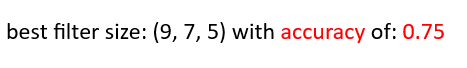


Training final model with best parameters on the full training dataset...
Epoch 1/15, Loss: 1.2737
Epoch 2/15, Loss: 1.0090
Epoch 3/15, Loss: 0.8705
Epoch 4/15, Loss: 0.7529
Epoch 5/15, Loss: 0.6582
Epoch 6/15, Loss: 0.5878
Epoch 7/15, Loss: 0.5210
Epoch 8/15, Loss: 0.4725
Epoch 9/15, Loss: 0.4226
Epoch 10/15, Loss: 0.3914
Epoch 11/15, Loss: 0.3562
Epoch 12/15, Loss: 0.3258
Epoch 13/15, Loss: 0.3047
Epoch 14/15, Loss: 0.2856
Epoch 15/15, Loss: 0.2682


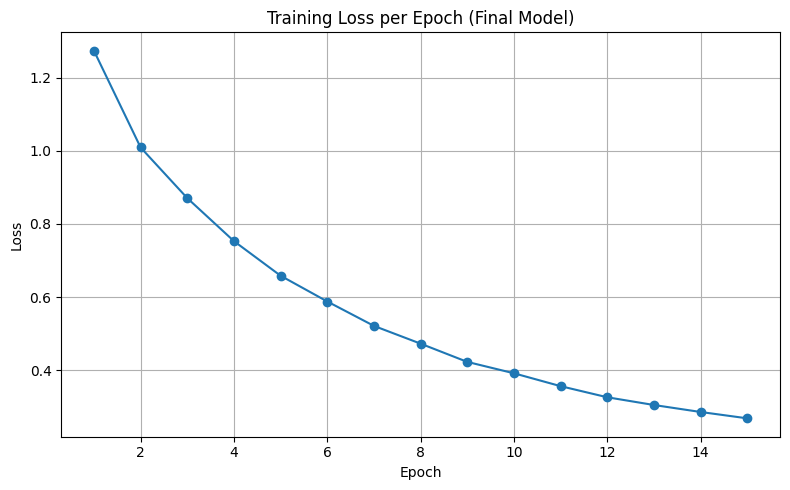

Final model and checkpoints saved in 'saved_models' directory with timestamp 20250519_163252


In [ ]:
# # Train and save the final model with best parameters
# if best_params:
#     print("\nTraining final model with best parameters on the full training dataset...")
#     final_model = CNN1D_LSTM(
#         input_length=x_train_tensor.shape[1],
#         num_classes=len(ohe.categories_[0]),
#         dropout_rate=best_params['dropout'],
#         kernel_sizes=best_params['kernel_sizes']
#     )
#     final_model = final_model.to(device)
#     final_optimizer = optim.Adam(final_model.parameters(), lr=0.001)
#     final_criterion = nn.CrossEntropyLoss()

#     loss_per_epoch = []
#     full_train_dataset = torch.utils.data.TensorDataset(x_train_tensor.unsqueeze(1), y_train_tensor)
#     full_train_loader = DataLoader(full_train_dataset, batch_size=best_params['batch_size'], shuffle=True)

#     timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#     best_final_loss = float('inf')

#     for epoch in range(best_params['epochs']):
#         final_model.train()
#         total_loss = 0
#         for inputs, labels in full_train_loader:
#             inputs, labels = inputs.to(device), labels.to(device)
#             final_optimizer.zero_grad()
#             outputs = final_model(inputs)
#             loss = final_criterion(outputs, labels)
#             loss.backward()
#             final_optimizer.step()
#             total_loss += loss.item()
        
#         epoch_loss = total_loss/len(full_train_loader)
#         loss_per_epoch.append(epoch_loss)
#         print(f"Epoch {epoch+1}/{best_params['epochs']}, Loss: {epoch_loss:.4f}")

#         # Save checkpoint every epoch
#         epoch_save_path = f'saved_models/final_model_epoch{epoch+1}_{timestamp}.pth'
#         torch.save({
#             'epoch': epoch,
#             'model_state_dict': final_model.state_dict(),
#             'optimizer_state_dict': final_optimizer.state_dict(),
#             'loss': epoch_loss,
#         }, epoch_save_path)

#         # Save best model
#         if epoch_loss < best_final_loss:
#             best_final_loss = epoch_loss
#             best_save_path = f'saved_models/final_model_best_{timestamp}.pth'
#             torch.save({
#                 'epoch': epoch,
#                 'model_state_dict': final_model.state_dict(),
#                 'optimizer_state_dict': final_optimizer.state_dict(),
#                 'loss': best_final_loss,
#             }, best_save_path)

#     # Save final trained model
#     final_save_path = f'saved_models/final_model_complete_{timestamp}.pth'
#     torch.save({
#         'model_state_dict': final_model.state_dict(),
#         'optimizer_state_dict': final_optimizer.state_dict(),
#         'loss_history': loss_per_epoch,
#         'best_params': best_params,
#         'best_val_acc': best_acc
#     }, final_save_path)

#     # Save loss history
#     with open(f'saved_models/final_model_loss_history_{timestamp}.txt', 'w') as f:
#         f.write('\n'.join(map(str, loss_per_epoch)))

#     #plot loss per epoch
#     plt.figure(figsize=(8, 5))
#     plt.plot(range(1, len(loss_per_epoch)+1), loss_per_epoch, marker='o', linestyle='-')
#     plt.title("Training Loss per Epoch (Final Model)")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(f'saved_models/final_model_loss_plot_{timestamp}.png')
#     plt.show()

#     print(f"Final model and checkpoints saved in 'saved_models' directory with timestamp {timestamp}")

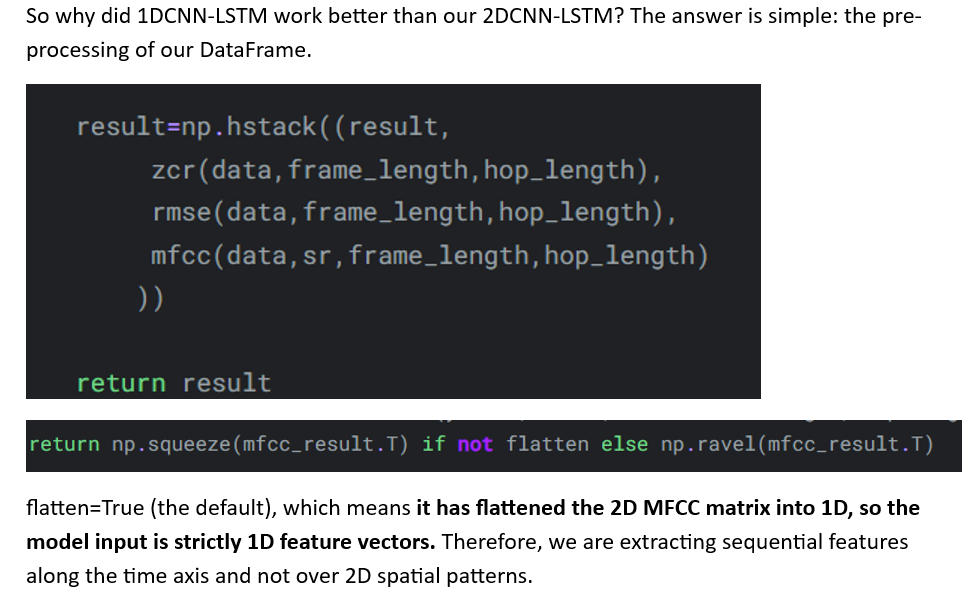